In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import gc

In [2]:
ds_sla = xr.open_dataset('SLA_UPDATED.nc')

In [3]:
ds_gfs = xr.open_dataset('GFS_UPDATED_V1.nc')

In [4]:
ocean_mask = ~ds_sla.sla.isel(time=0).isnull()

In [5]:
lat_idxs,lon_idxs = np.where(ocean_mask)

In [6]:
sla_now = ds_sla.sla

ds_ml = xr.Dataset({
        "sla_now": sla_now,
        
        **{
        f"sla_lag{i}": ds_sla.sla.shift(time=i)
        for i in range(1,15)
        },

        "tmp_surface": ds_gfs.TMP_surface,
        "tmp_2m": ds_gfs.TMP_2maboveground,

        "ugrd": ds_gfs.UGRD_10maboveground,
        "vgrd": ds_gfs.VGRD_10maboveground,

        "dswrf": ds_gfs.DSWRF_surface,
        "uswrf": ds_gfs.USWRF_surface,
        "dlwrf": ds_gfs.DLWRF_surface,
        "ulwrf": ds_gfs.ULWRF_surface,

        "spfh": ds_gfs.SPFH_2maboveground,
        "prate": ds_gfs.PRATE_surface,

        
    })
ds_ml["month"] = ds_ml.time.dt.month
ds_ml["dayofyear"] = ds_ml.time.dt.dayofyear

In [7]:
features = (
    ["sla_now"]
    + [f"sla_lag{i}" for i in range(1,15)]
    + [
        "tmp_surface",
        "tmp_2m",
        "ugrd",
        "vgrd",
        "dswrf",
        "uswrf",
        "dlwrf",
        "ulwrf",
        "spfh",
        "prate",
        "month",
        "dayofyear",
        "latitude",
        "longitude"
    ]
)

In [8]:
ds_ml = ds_ml.stack(
    point=("latitude","longitude")
)
df_features = (ds_ml.to_dataframe().reset_index()).dropna()

In [9]:
def build_Dataset(lead):

    target = ds_sla.sla.shift(time=-lead).where(ocean_mask).stack(point=("latitude","longitude"))
    
    target_df = target.to_dataframe(name="target").reset_index()
    
    df = df_features.merge(
    target_df,
    on=["time","latitude","longitude"]
    )
    
    df = df.dropna(subset=['target'])
    
    train = df[df.time < "2024-01-01"]
    test  = df[df.time >= "2024-01-01"]
    
    X_train = train[features]
    y_train = train["target"]
    X_test = test[features]
    y_test = test["target"]
    
    
    coords_test = test[["time", "latitude", "longitude"]]
    
    return X_train, y_train, X_test, y_test,coords_test

In [10]:
def train_and_evaluate(lead):
    X_train, y_train, X_test, y_test,coords_test = build_Dataset(lead)
    model = XGBRegressor(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device="cuda",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)
    model.set_params(device="cpu")
    pred_xgb = model.predict(X_test)

    rmse_xgb = np.sqrt(
        mean_squared_error(
            y_test,
            pred_xgb
        )
    )
    pred_persistence = X_test["sla_now"]
    rmse_persistence = np.sqrt(
        mean_squared_error(
            y_test,pred_persistence
        )
    )
    
    pred_df = coords_test.copy()

    pred_df["truth"] = y_test.values
    pred_df["xgb"] = pred_xgb
    pred_df["pers"] = pred_persistence.values

    pred_df["err_xgb"] = pred_xgb - y_test.values
    pred_df["err_pers"] = pred_persistence.values - y_test.values
    
    rmse_map = (
        pred_df
        .groupby(["latitude","longitude"])
        .agg(
            rmse_xgb=("err_xgb",
                    lambda x: np.sqrt(np.mean(x**2))),
            rmse_pers=("err_pers",
                    lambda x: np.sqrt(np.mean(x**2)))
        )
        .reset_index()
    )
    
    rmse_map["improvement"] = (
        rmse_map["rmse_pers"]
        - rmse_map["rmse_xgb"]
    )
        
    return rmse_xgb, rmse_persistence, model, X_test,rmse_map,pred_df
    
    

Lead 1: Persistence=0.01848, XGB=0.01972


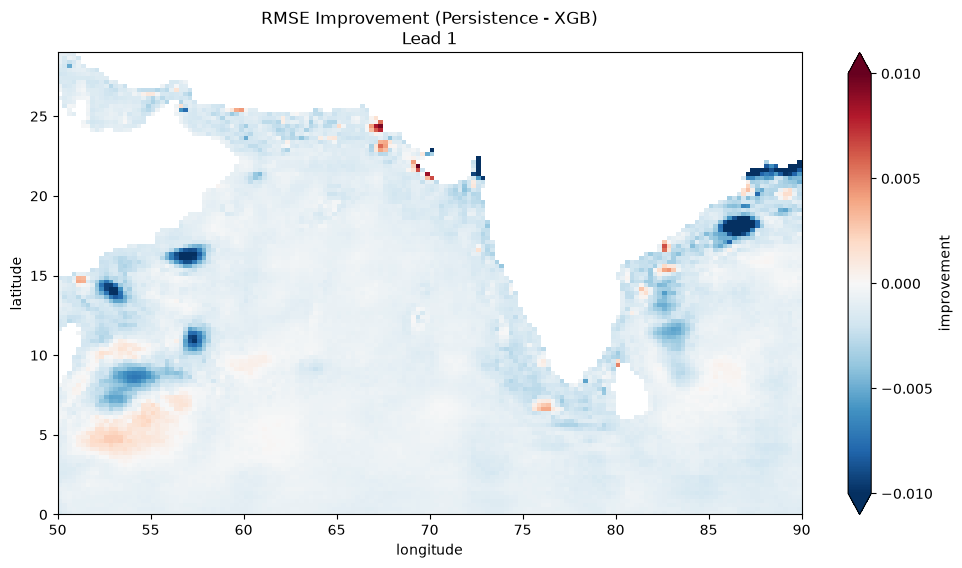

Lead 2: Persistence=0.02329, XGB=0.02499


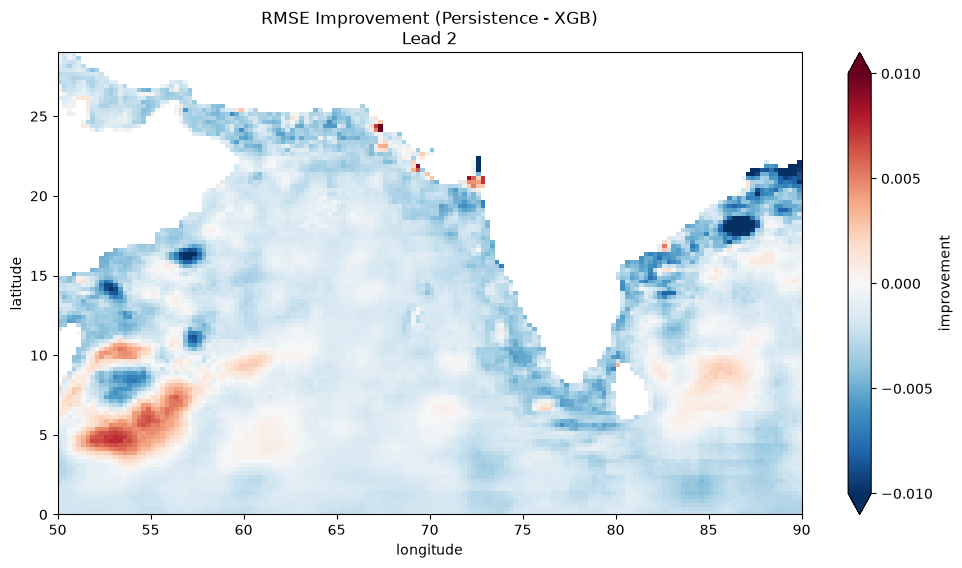

Lead 3: Persistence=0.02836, XGB=0.03026


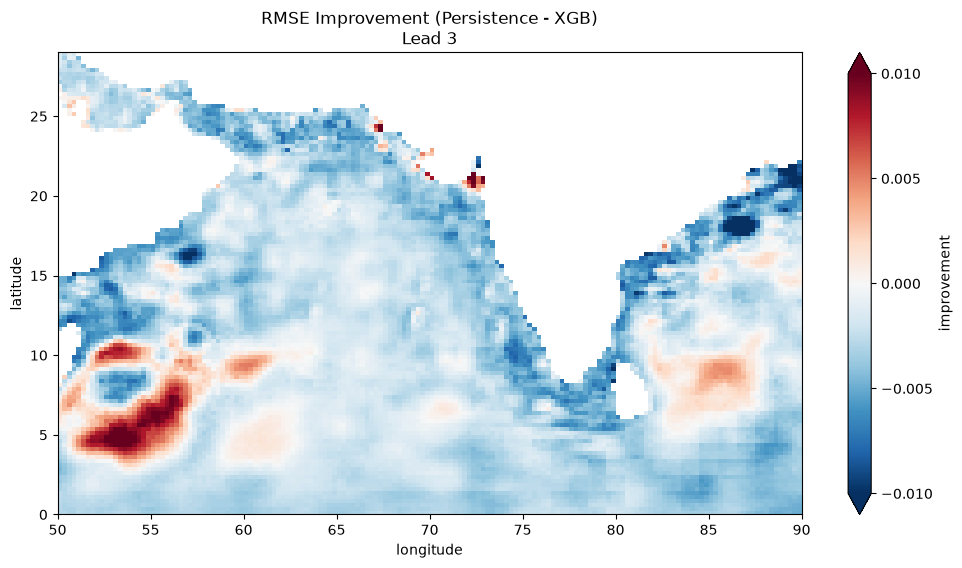

Lead 4: Persistence=0.03372, XGB=0.03518


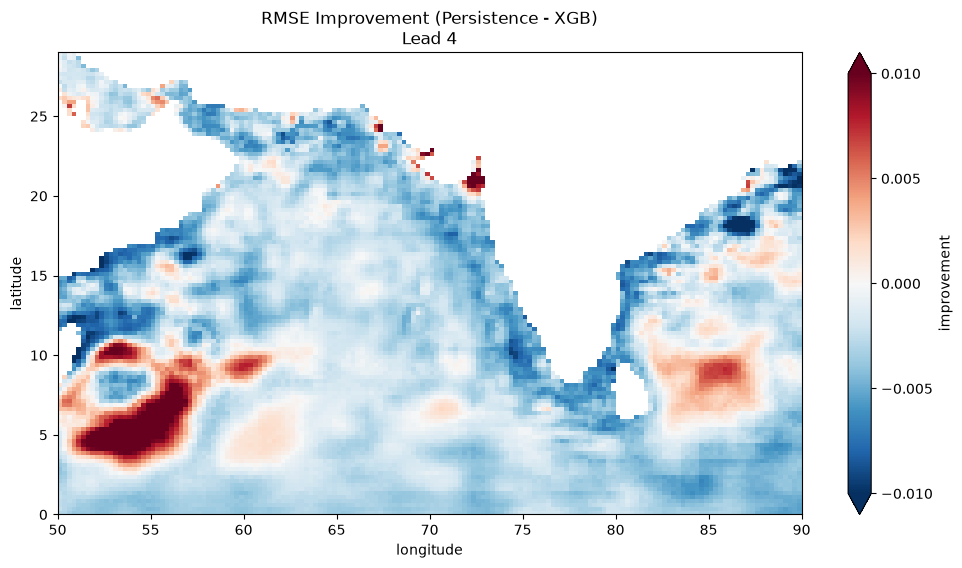

Lead 5: Persistence=0.03848, XGB=0.03899


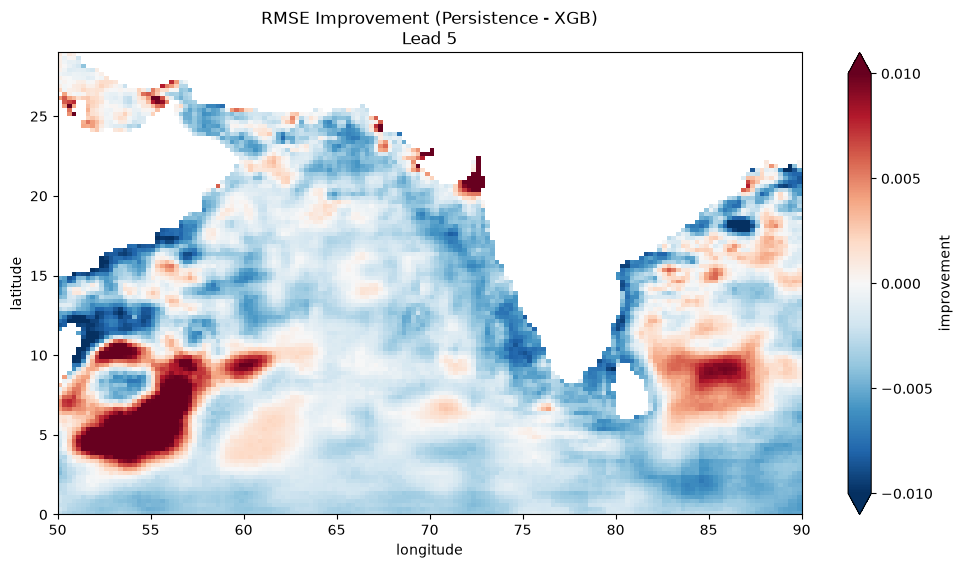

Lead 6: Persistence=0.04307, XGB=0.04274


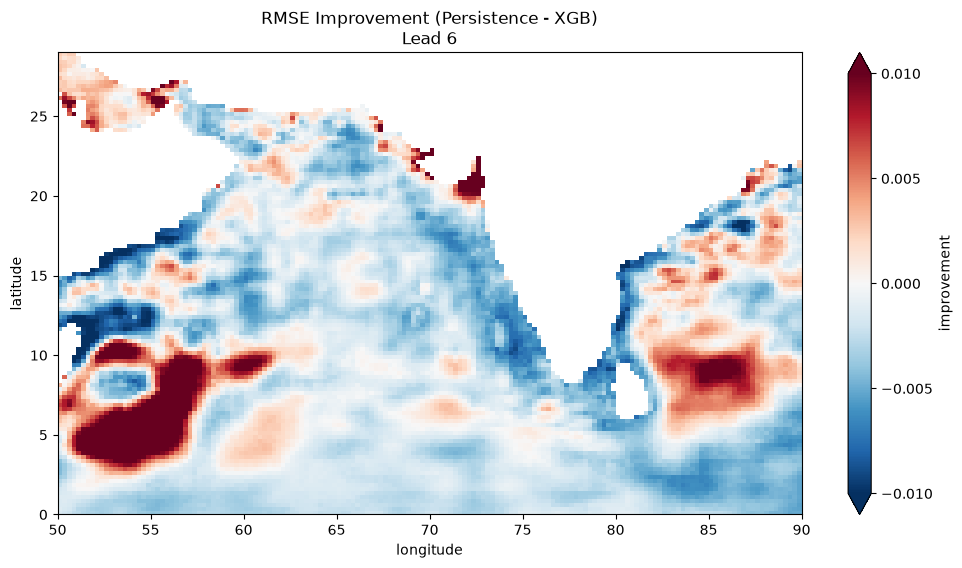

Lead 7: Persistence=0.04710, XGB=0.04548


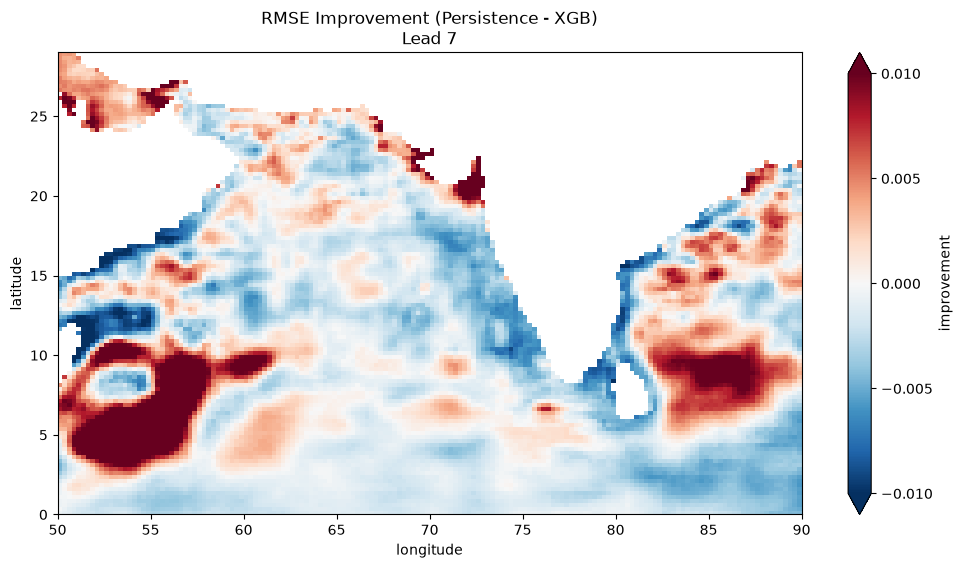

In [ ]:
results = []

for lead in range(1, 8):

    rmse_xgb, rmse_persistence, model, X_test,rmse_map,pred_df = train_and_evaluate(lead)

    results.append({
        "lead": lead,
        "xgb": rmse_xgb,
        "persistence": rmse_persistence
    })

    print(
        f"Lead {lead}: "
        f"Persistence={rmse_persistence:.5f}, "
        f"XGB={rmse_xgb:.5f}"
    )
    
    improvement_da = (
    rmse_map
    .set_index(["latitude","longitude"])
    ["improvement"]
    .to_xarray()
    )

    plt.figure(figsize=(12,6))

    improvement_da.plot(
        cmap="RdBu_r",
        vmin=-0.01,
        vmax=0.01,
        cbar_kwargs={
        "ticks": np.linspace(-0.01, 0.01, 5)
        }
    )
    

    # Save RMSE table for this lead
    rmse_map.to_parquet(
        f"rmse_map_lead/rmse_map_lead_{lead}.parquet"
    )

    # Save trained XGBoost model
    model.save_model(
        f"model_info/xgb_lead_{lead}.json"
    )

    # Save gridded improvement map
    improvement_da.to_netcdf(
        f"improv_leadnc/improvement_lead_{lead}.nc"
    )
    
    # Save pred features
    pred_df.to_parquet(
    f"pred_lead/predictions_lead_{lead}.parquet"
    )
    
    plt.title(
        f"RMSE Improvement (Persistence - XGB)\nLead {lead}"
    )
    plt.savefig(
        f"improv_leadpng/improvement_lead_{lead}.png",
        dpi=300,
        bbox_inches="tight"
    )

    del model
    del X_test
    del rmse_map
    del pred_df
    del improvement_da

    gc.collect()
    
results_df = pd.DataFrame(results)
results_df.to_parquet(
"rmse_summary.parquet"
)
    

In [ ]:
# results_df = pd.DataFrame(results)

# results_df.to_parquet(
#     "rmse_summary.parquet"
# )

In [13]:
print(df_features.memory_usage(deep=True).sum() / 1024**3)

6.407370995730162


In [17]:
import psutil

print("Total RAM:", psutil.virtual_memory().total / 1024**3, "GB")
print("Available:", psutil.virtual_memory().available / 1024**3, "GB")

Total RAM: 62.40180969238281 GB
Available: 36.34204864501953 GB
